# ML Homework 2 Guide


1. Save a copy of this ipynb file in your GoogleDrive or PC.
2. Edit the name of this code from "HW2.ipynb" to "HW2\_(your name).ipynb"
3. Fill out the code cells below according to descriptions.
4. Save and upload to BrightSpace. (DO NOT clear the outputs of your code)
5. Convert the .ipynb file to PDF file and upload together


# [HW 2-1] Feature Extraction

Extract features from EXAMPLE DATASET according to following instructions:

1. Load 60 normal data and 60 abnormal data (Normal_1 ~ 60, Abnormal_1 ~ 60)
2. Extract features from acceleration and voltage signal (EXCLUDING current)
3. Extract 3 types of feature: Max, Min, Mean
4. Extract features from ONLY FREQUENCY (NOT Time) domains (WT coefficients)
5. Set the MOTHER WAVELET to 'sym3'
6. Set the wavelet decomposition level to 4

- Number of features: 3 features _ 2 sensors _ 4 WT levels = 24 features (per data)

- Refer to ML3_Code1


In [20]:
import pandas as pd
import numpy as np
import scipy.stats as sp
import pywt
import matplotlib.pyplot as plt
import time

In [21]:
# Declare the size of feature dataset
NoOfData = 120  # 120 data per condition (normal/abnormal) per instruction 1
NoOfSensor = (
    2  # 2 sensors (acceleration, voltage) exclude current per instruction 2
)
# Note - I could not find where the columns are declared and it appears that
# the data does not have headers. I am assuming that the last column is current.
NoOfFeature = 3  # 3 features (max, min, mean)

# Load raw dataset (120 files)
from urllib.error import HTTPError

for i in range(NoOfData):

    temp_path1 = f"https://github.com/purduelamm/purdue_me597_iiot/blob/main/ml_tutorial/Dataset/Normal_{i+1}?raw=true"  # File path of temporary normal data
    temp_path2 = f"https://github.com/purduelamm/purdue_me597_iiot/blob/main/ml_tutorial/Dataset/Abnormal_{i+1}?raw=true"  # File path of temporary abnormal data

    try:
        exec(
            f"Normal_{i+1}   = pd.read_csv(temp_path1 , sep=',' , header=None)"
        )
    except HTTPError:
        print(f"Failed to load data for file Normal_{i+1}")
    try:
        exec(
            f"Abnormal_{i+1} = pd.read_csv(temp_path2 , sep=',' , header=None)"
        )
    except HTTPError:
        print(f"Failed to load data for file Abnormal_{i+1}")

# Set wavelet transform options
MotherWavelet = pywt.Wavelet(
    "sym3"
)  # Mother wavelet set to Symlet 3 per instruction 5
Level = 4  # Wavelet decomposition level set to 4 per instruction 6

# Create empty(0) arrays for normal/abnormal feature dataset
FreqFeature_Normal = np.zeros(
    shape=(NoOfSensor * NoOfFeature * Level, NoOfData)
)
FreqFeature_Abnormal = np.zeros(
    shape=(NoOfSensor * NoOfFeature * Level, NoOfData)
)

# Frequency domain feature extraction
# Skipping time domain per instruction 4
for i in range(NoOfData):

    # Declare temporary data (only sensor signals)
    exec(f"temp_data1 = Normal_{i+1}.iloc[:,1:]")
    exec(f"temp_data2 = Abnormal_{i+1}.iloc[:,1:]")

    # Walvelet decomposition
    Coef1 = pywt.wavedec(temp_data1, MotherWavelet, level=Level, axis=0)
    Coef2 = pywt.wavedec(temp_data2, MotherWavelet, level=Level, axis=0)

    # Frequency domain feature extraction
    for j in range(NoOfSensor):

        for k in np.arange(Level):
            coef1 = Coef1[Level - k]
            coef2 = Coef2[Level - k]

            ##################################################
            # Assuming the indexes of max, min, mean, etc. are
            # the same as time domain features, but with an
            # additional level factor (k):
            # FreqFeature_Normal[(j * Level + k) * NoOfFeature + feature_index, i]
            ##################################################

            index_base = (j * Level + k) * NoOfFeature
            # Normal features
            # Only extracting max, min, mean per instruction 3
            FreqFeature_Normal[index_base + 0, i] = np.max(coef1[:, j])
            FreqFeature_Normal[index_base + 1, i] = np.min(coef1[:, j])
            FreqFeature_Normal[index_base + 2, i] = np.mean(coef1[:, j])

            # Abnormal features
            # Only extracting max, min, mean per instruction 3
            FreqFeature_Abnormal[index_base + 0, i] = np.max(coef2[:, j])
            FreqFeature_Abnormal[index_base + 1, i] = np.min(coef2[:, j])
            FreqFeature_Abnormal[index_base + 2, i] = np.mean(coef2[:, j])

# Result
FreqFeature = np.concatenate(
    [FreqFeature_Normal, FreqFeature_Abnormal], axis=1
)
FreqFeature.shape

(24, 240)

# [HW2-2]

Reduce demension of the above featureset (12-D) to 2-D based on t-SNE and Visualize it.

- Don't need to select features
- Refer to ML4_Code2


In [22]:
from sklearn.manifold import TSNE  # Import a package for t-SNE
from sklearn.preprocessing import StandardScaler, MinMaxScaler

[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 240 samples in 0.000s...
[t-SNE] Computed neighbors for 240 samples in 0.007s...
[t-SNE] Computed conditional probabilities for sample 240 / 240
[t-SNE] Mean sigma: 1.872692
[t-SNE] KL divergence after 250 iterations with early exaggeration: 48.041214
[t-SNE] KL divergence after 500 iterations: 0.398657


 t-SNE done! Time elapsed: 0.15032625198364258 seconds




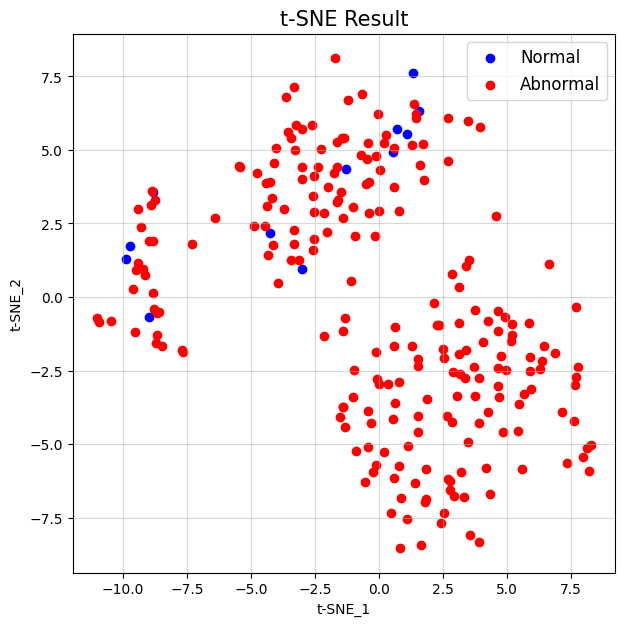

In [23]:
# Data Standardization
FeatureSelected_std = StandardScaler().fit_transform(
    FreqFeature.T
)  # Transposing to account for not selecting data
pd.DataFrame(FeatureSelected_std)


# t-SNE Implementation
dim = 2
time_start = time.time()
tsne = TSNE(
    n_components=dim, verbose=1, perplexity=50, max_iter=500, random_state=1
)
# 'perplexity' is generally set to a value between 5 and 50.
tsne_results = tsne.fit_transform(FeatureSelected_std)

print(
    "\n\n t-SNE done! Time elapsed: {} seconds\n\n".format(
        time.time() - time_start
    )
)

pd.DataFrame(tsne_results)

# Visualization of t-SNE Result
NoOfData = int(FreqFeature.shape[0] / 2)

plt.figure(figsize=(7, 7))

plt.scatter(
    tsne_results[:NoOfData, 0],
    tsne_results[:NoOfData, 1],
    marker="o",
    label="Normal",
    c="b",
)
plt.scatter(
    tsne_results[NoOfData:, 0],
    tsne_results[NoOfData:, 1],
    marker="o",
    label="Abnormal",
    c="r",
)
plt.title("t-SNE Result", fontsize=15)
plt.grid(alpha=0.5)
plt.legend(fontsize=12)
plt.xlabel("t-SNE_1")
plt.ylabel("t-SNE_2")

plt.show()

## ML3 and ML4 Summary and Deliverables

Answer the following questions for your achievements


### Q1. Please summarize ML3 and ML4.

---

In ML3, we extracted time and frequency domain features from a large dataset. 180 files were described as being in a normal state, while an additional 180 were described as being in an abnormal state. 10 feature types were analyzed for ML3, max, min, mean, rms, variance, skewness, kurtosis, crest, shape, and impulse. We transformed the available data using a haar mother wavelet with 8 decomposition levels. Using this decomposition, we were able to use a t-test or P-value calculation to assess how distinct the normal and abnormal data was. The data was analyzed using a probabilistic density function represented by a histogram which demonstrated that the normal and abnormal data were well distinguished.

In ML4, we used the same dataset with the P-value ranking and normalized the data by scaling it with the min and max of the data. We then reduced the dimensionality of the data using a principal components analysis of the standard deviation. Additionally, we implemented t-SNE to try reducing the dimensions using another method.

---


### Q2. What skills did you have to develop to accomplish this project?

---

To accomplish this project, I developed better data analysis skills using pandas dataframes. I also developed my skills in the use of the scikit module. Finally, I learned more about wavelets, t-test calculattions, and different methods to reduce the dimensionality of a dataset.

---


### Q3. What aspects of this project were the most beneficial for your learning?

---

The aspects of this project that were the most beneficial for my learning was being able to view an actual dataset and graphically see how the dimensions were being reduced. It also helped my understanding to visually see on the graphs  how the lower p-values were far more distinct than the higher ones.

---


### Q4. What challenges did you encounter in completing the project?

---

In completing this project, I had challenges understanding how to properly index the data in ML3_Code1. I was confused how to use NoOfFeature, Level, j and k together to properly index the data. For many of my attempts I would end up missing a lot of the data with arrays full of zeroes at the end. In addition, I had some difficulties figuring out how to only select voltage and acceleration without selecting current.

---


### Q5. How did you overcome the challenges or remedy the problems encountered?

---

To overcome these challenges, I first wrote down by hand on a whiteboard what the columns would look like. I made this process easier by using fewer features in my hand calculations.
To overcome the challenge of not knowing how to select the correct sensor outputs, I simply assumed that the data from the .csv files would follow the order given in the comment of ML3_Code1 which stated that the sensor signals would be in the order of acceleration, voltage and then current so I assumed that only selecting 2 sensors would give me the right dataset.

---
